## NOX Injector Sizing
*DukeAERO Project Prometheus*

Last edited 9/15/2026 by Ethan Rosenfeld

Sources:
- [Mass Flow Rate and Isolation Characteristics of Injectors
for Use with Self-Pressurizing Oxidizers in Hybrid Rockets](https://ntrs.nasa.gov/api/citations/20190001326/downloads/20190001326.pdf)

In [1]:
try:
  import CoolProp
except:
  !pip install CoolProp

import numpy as np
import CoolProp.CoolProp as CP
from CoolProp.CoolProp import AbstractState
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [2]:
IN = 0.0254
PSI = 6894.76

In [3]:
# Constants
target_burn_time = 6
target_n2o_mdot = 1.249
buffer_n2o = 0
ullage_fraction = 0.1
starting_pressure = 900 * PSI
discharge_coefficient = 0.75
chamber_pressure = 400 * PSI

# Annulus sizing
pintle_diameter = 0.82 * IN
outer_radius = (pintle_diameter/2) + (0.027 * IN)
area = np.pi * (outer_radius**2 - (pintle_diameter/2)**2)

# Single-phase incompressible mass flow rate
def mdot_spi(upstream_pressure, downstream_pressure):
    pressure_difference = upstream_pressure - downstream_pressure
    rho_liq = CP.PropsSI('D', 'P', upstream_pressure, 'Q', 0, 'N2O')
    return discharge_coefficient * area * np.sqrt(2 * rho_liq * pressure_difference)

# Homogenous equilibrium model mass flow rate
def mdot_hem(upstream_pressure, downstream_pressure):
    upstream_enthalpy = CP.PropsSI('H', 'P', upstream_pressure, 'Q', 0, 'N2O')
    upstream_entropy = CP.PropsSI('S', 'P', upstream_pressure, 'Q', 0, 'N2O')
    downstream_enthalpy = CP.PropsSI('H', 'P', downstream_pressure, 'S', upstream_entropy, 'N2O')
    rho_chamber = CP.PropsSI('D', 'P', downstream_pressure, 'S', upstream_entropy, 'N2O')
    return discharge_coefficient * area * rho_chamber * np.sqrt(2 * (upstream_enthalpy - downstream_enthalpy))

# Find maximum of HEM mass flow rate
def mdot_hem_crit(upstream_pressure, downstream_lower_bound=None, downstream_upper_bound=None):
    if downstream_upper_bound is None:
        downstream_upper_bound = 0.999 * upstream_pressure
    if downstream_lower_bound is None:
        downstream_lower_bound = 0.01 * upstream_pressure

    result = minimize_scalar(
        lambda downstream_pressure: -mdot_hem(upstream_pressure, downstream_pressure),
        bounds=(downstream_lower_bound, downstream_upper_bound),
        method='bounded'
    )

    return result.x

# Dyer non-homogenous non-equilibrium mass flow rate
def mdot(upstream_pressure, chamber_pressure):
    k_dyer = np.sqrt((upstream_pressure - chamber_pressure) / (upstream_pressure - chamber_pressure)) # Just 1 for self-pressurized N2O
    spi_weight = k_dyer / (1 + k_dyer)
    hem_weight = 1 / (1 + k_dyer)

    # Check choked condition
    critical_chamber_pressure = mdot_hem_crit(upstream_pressure)
    if chamber_pressure < critical_chamber_pressure:
        chamber_pressure = critical_chamber_pressure

    mass_flow = spi_weight * mdot_spi(upstream_pressure, chamber_pressure) + hem_weight * mdot_hem(upstream_pressure, chamber_pressure)
    return mass_flow

# Initial NOX tank state
rho_liq_init = CP.PropsSI('D', 'P', starting_pressure, 'Q', 0, 'N2O')
rho_vap_init = CP.PropsSI('D', 'P', starting_pressure, 'Q', 1, 'N2O')
rho_vap_fin = CP.PropsSI('D', 'P', 560 * PSI, 'Q', 1, 'N2O')
u_liq_init = CP.PropsSI('U', 'P', starting_pressure, 'Q', 0, 'N2O')
u_vap_init = CP.PropsSI('U', 'P', starting_pressure, 'Q', 1, 'N2O')

required_burn_n2o = target_burn_time * target_n2o_mdot
required_ullage_n2o = ((required_burn_n2o + buffer_n2o) / rho_liq_init) * rho_vap_fin
launch_liq_n2o = required_burn_n2o + required_ullage_n2o + buffer_n2o
launch_vap_n2o = ullage_fraction * (launch_liq_n2o / rho_liq_init) * rho_vap_init
tank_vol = launch_liq_n2o / rho_liq_init + launch_vap_n2o / rho_vap_init

m = launch_liq_n2o + launch_vap_n2o
U = launch_liq_n2o * u_liq_init + launch_vap_n2o * u_vap_init

# Blowdown simulation
AS = AbstractState("HEOS", "N2O")
t = 0
dt = 0.05
results = []

while m > 0:
    rho_avg = m / tank_vol
    U_avg = U / m
    AS.update(CP.DmassUmass_INPUTS, rho_avg, U_avg)
    T = AS.T()
    P = AS.p()
    Q = AS.Q()

    if Q >= 0.999 or Q < 0:
        break

    mass_flow = mdot(P, chamber_pressure)

    h_liq_out = CP.PropsSI('H', 'P', P, 'Q', 0, 'N2O') if Q < 1 else CP.PropsSI('H', 'T', T, 'Q', 1, 'N2O')

    dm = mass_flow * dt
    dU = mass_flow * h_liq_out * dt

    m -= dm
    U -= dU
    t += dt
    results.append((t, m, mass_flow, U, P/PSI, T - 273.15))

Burn ended at t=5.70s
Mass flow: 1.448 -> 1.155 kg/s
Pressure: 900.0 -> 559.7 psi


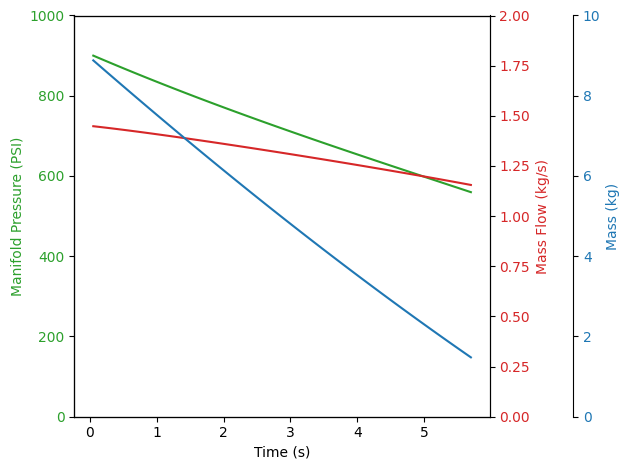

In [20]:
# Results
times, masses, mass_flows, energies, pressures, temps = [np.array([r[i] for r in results]) for i in range(len(results[0]))]

print(f"Burn ended at t={times[-1]:.2f}s")
print(f"Mass flow: {mass_flows[0]:.3f} -> {mass_flows[-1]:.3f} kg/s")
print(f"Pressure: {pressures[0]:.1f} -> {pressures[-1]:.1f} psi")

# Plotting
fig, ax1 = plt.subplots()
ax1.set_xlabel('Time (s)')
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

plots = [
    [ax1, pressures, (0, 1000), "Manifold Pressure (PSI)", 'tab:green'],
    [ax2, mass_flows, (0, 2), "Mass Flow (kg/s)", 'tab:red'],
    [ax3, masses, (0, 10), "Mass (kg)", 'tab:blue'],
]

for plot in plots:
    color = plot[4]
    ax = plot[0]
    ax.set_ylabel(plot[3], color=color)
    ax.plot(times, plot[1], color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.set_ylim(*plot[2])

fig.tight_layout()
plt.show()